<a href="https://colab.research.google.com/github/mteuslms/AI-ML-projects/blob/main/LLMs_and_Transformers/Deceptive_Style_Classifier__BonusAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bonus Assignment

## The "Deceptive Style Classifier." (Fake News Classifier)


The Data: WELFake
What it is: A collection of ~72,000 news articles. It is balanced (half real, half fake), which prevents the  model from developing a bias toward one class.

Structure: It has four main columns: Serial number, Title, Text, and Label (0 for fake, 1 for real).

Where to get it: we can download the CSV directly from Kaggle (search for "WELFake dataset").

0=fake 1=real


In [ ]:
#using fastai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv

from fastai.text.all import *
import torch.nn as nn

# checking for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Read the data
# the full data is available at this link
path = '/content/WELFake_Dataset.csv'

# Increase the field size limit to handle potentially very long text fields
csv.field_size_limit(10000000) # Setting a higher limit, e.g., 10MB

df = pd.read_csv(path, engine='python')
df.head()

cuda


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO],"No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others on a radio show Tuesday night to turn the tide and kill white people and cops to send a message about the killing of black people in America.One of the F***YoFlag organizers is called Sunshine. She has a radio blog show hosted from Texas called, Sunshine s F***ing Opinion Radio Show. A snapshot of her #FYF911 @LOLatWhiteFear Twitter page at 9:53 p.m. shows that she was urging supporters to Ca...",1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of North Carolina [VIDEO],"Now, most of the demonstrators gathered last night were exercising their constitutional and protected right to peaceful protest in order to raise issues and create change. Loretta Lynch aka Eric Holder in a skirt",1
3,3,"Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid","A dozen politically active pastors came here for a private dinner Friday night to hear a conversion story unique in the context of presidential politics: how Louisiana Gov. Bobby Jindal traveled from Hinduism to Protestant Christianity and, ultimately, became what he calls an “evangelical Catholic.”\n\nOver two hours, Jindal, 42, recalled talking with a girl in high school who wanted to “save my soul,” reading the Bible in a closet so his parents would not see him and feeling a stir while watching a movie during his senior year that depicted Jesus on the cross.\n\n“I was struck, and struck...",0
4,4,SATAN 2: Russia unvelis an image of its terrifying new ‘SUPERNUKE’ – Western world takes notice,"The RS-28 Sarmat missile, dubbed Satan 2, will replace the SS-18 Flies at 4.3 miles (7km) per sec and with a range of 6,213 miles (10,000km) The weapons are perceived as part of an increasingly aggressive Russia It could deliver a warhead of 40 megatons – 2,000 times as powerful as the atom bombs dropped on Hiroshima and Nagasaki in 1945 By LIBBY PLUMMER and GARETH DAVIE S Russia has unveiled chilling pictures of its largest ever nuclear missile, capable of destroying an area the size of France. The RS-28 Sarmat missile, dubbed Satan 2 by Nato, has a top speed of 4.3 miles (7km) per second...",1


**Now I want to check for class balance and missing values, so lets do a value_counts() on the label column 0 = fake and 1 = real**

In [ ]:
df["label"].value_counts()

,count
label,
1,37106
0,35028


Now lets combine **Title** and **Body** columns into a new **full_news** column

In [ ]:
# Ensuring all values are strings to avoid errors if there are empty/NaN cells
df['title'] = df['title'].fillna("")
df['text'] = df['text'].fillna("")

# Combine them into a new feature
df['full_news'] = df['title'] + " " + df['text']

# Quick check of the first entry
print(df['full_news'].iloc[0])

LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others on a radio show Tuesday night to  turn the tide  and kill white people and cops to send a message about the killing of black people in America.One of the F***YoFlag organizers is called  Sunshine.  She has a radio blog show hosted from Texas called,  Sunshine s F***ing Opinion Radio Show. A snapshot of her #FYF911 @LOLatWhiteFear Twitter page at 9:53 p.m. shows that she was urging supporters to  Call now!! #fyf911 tonight we continue to dismantle the illusion of white Below is a SNAPSHOT Twitter Radio Call Invite   #FYF911The radio show aired at 10:00 p.m. eastern standard time.During the show, callers clearly call for  lynching  and  killing  of white people.A 2:39

## Model Training

vocab_size: 60008
[0, 0.11853107810020447, 0.05852479860186577, 0.979550838470459, '01:12']
[1, 0.05490780621767044, 0.04945649951696396, 0.9852349758148193, '01:12']
[2, 0.0269487164914608, 0.03738380968570709, 0.9897407293319702, '01:11']
[3, 0.05163191258907318, 0.040861375629901886, 0.9873839020729065, '01:13']
[4, 0.04329180344939232, 0.0318286307156086, 0.9907805323600769, '01:12']
[5, 0.024161584675312042, 0.03724747523665428, 0.9899486899375916, '01:13']
[6, 0.026764696463942528, 0.03524121269583702, 0.9918203353881836, '01:13']
[7, 0.09572845697402954, 0.033245544880628586, 0.9893248081207275, '01:12']
[8, 0.12137694656848907, 0.027408087626099586, 0.9915430545806885, '01:12']
[9, 0.009288745000958443, 0.11491002142429352, 0.9769859910011292, '01:13']


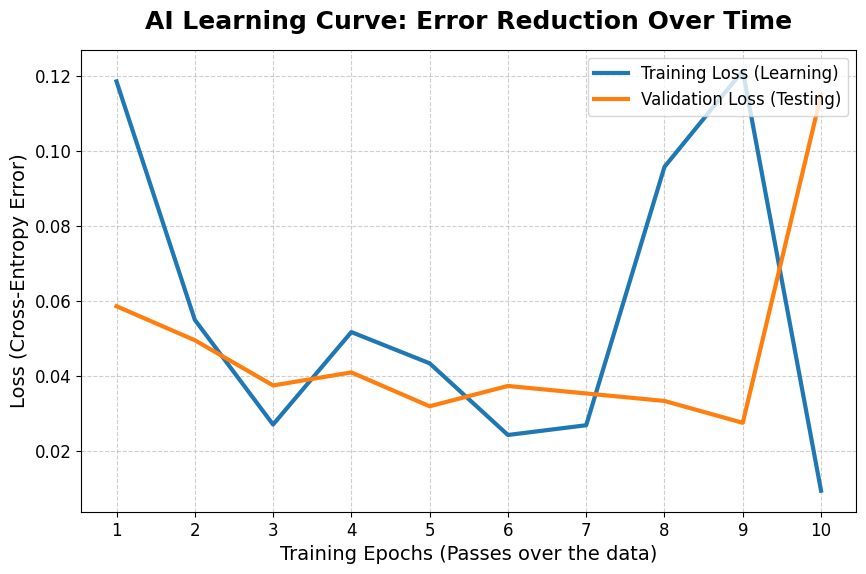

Train Accuracy: 0.9816176295280457
Validation Accuracy: 0.9769859910011292


In [ ]:
from fastai.text.all import *
import torch.nn as nn
import matplotlib.pyplot as plt

# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

wl = 600 # word length based on the Fake News EDA
outfile = open('fake_news_results.txt', 'w')

# Step 1: prepare the data loader using FastAI
dls = TextDataLoaders.from_df(
    df,                     # the fake news DataFrame
    text_col='full_news',   # The column concatenated earlier
    label_col='label',      # 0 for fake, 1 for real
    valid_pct=0.2,
    bs=64,
    seq_len=wl,
    seed=17,
    device=device
)

# Step 2: Build the neural network
embed_size = 300
vocab_size = len(dls.vocab[0])
print("vocab_size:", vocab_size)

model = nn.Sequential(
    nn.Embedding(vocab_size, embed_size),
    nn.AdaptiveAvgPool2d((1, embed_size)), # Pooling layer
    nn.Flatten(),                          # Flatten to 2D
    nn.Linear(embed_size, 64),
    nn.ReLU(),
    nn.Linear(64, 256),
    nn.ReLU(),
    nn.Linear(256, 1024),
    nn.ReLU(),
    nn.Linear(1024, 64),
    nn.ReLU(),
    nn.Linear(64, 2)                       # Output: 2 classes (Fake/Real)
)

# Step 3: Train the model
learn = Learner(dls, model, loss_func=nn.CrossEntropyLoss(), metrics=accuracy)


from fastai.callback.progress import ProgressCallback
learn.remove_cb(ProgressCallback)
# -------------------------------------------------------------

# Start the training
learn.fit(n_epoch=10, lr=0.001)

# 1. Extract the loss data from FastAI's secret recorder
# learn.recorder.values stores [train_loss, valid_loss, accuracy] for each epoch
train_losses = [val[0] for val in learn.recorder.values]
valid_losses = [val[1] for val in learn.recorder.values]
epochs = range(1, len(train_losses) + 1)

# 2. Set up a large, presentation-ready canvas
plt.figure(figsize=(10, 6))

# 3. Plot both lines with thick lines and distinct colors
plt.plot(epochs, train_losses, label='Training Loss (Learning)', color='#1f77b4', linewidth=3)
plt.plot(epochs, valid_losses, label='Validation Loss (Testing)', color='#ff7f0e', linewidth=3)

# 4. Add professional labels and titles
plt.title('AI Learning Curve: Error Reduction Over Time', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Training Epochs (Passes over the data)', fontsize=14)
plt.ylabel('Loss (Cross-Entropy Error)', fontsize=14)

# 5. Clean up the grid and legend for readability
plt.xticks(epochs, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# 6. Display the graph!
plt.show()

# Step 4: Validate and save results
train_loss, train_accuracy = learn.validate(dl=dls.train)
print(f"Train Accuracy: {train_accuracy}")

valid_loss, valid_accuracy = learn.validate(dl=dls.valid)
print(f"Validation Accuracy: {valid_accuracy}")

outfile.write("train_accuracy="+str(train_accuracy) + "\n")
outfile.write("valid_accuracy="+str(valid_accuracy) + "\n")
outfile.close()

**Looks like the model was well-trained, now let's add ourselves our own article as a check**

Test 1: Clickbait style news

In [ ]:
# 1. Write a custom news snippet (Let's try a classic fake clickbait style)
test_article = "SHOCKING: Aliens found building pyramids in Antarctica! Government covers it up, says top scientist. Click here to read the truth they don't want you to know!"

# 2. Tokenize the text using your dls (DataLoaders) tokenizer
tokens = dls.tokenizer(test_article)
numericalized_tokens = dls.numericalize(tokens)

# 3. Create a mini-batch with only the input data
test_dl = dls.test_dl([numericalized_tokens], with_labels=False)

# 4. Get the predictions
preds, _ = learn.get_preds(dl=test_dl)

# 5. Extract the class
pred_class_idx = torch.argmax(preds, dim=-1).item()
pred_class = dls.vocab[1][pred_class_idx]

if pred_class == 1:
    print(f"🚨 FAKE DETECTED! Prediction: Fake News (Class {pred_class})")
else:
    print(f"✅ Looks Credible. Prediction: Real News (Class {pred_class})")

🚨 FAKE DETECTED! Prediction: Fake News (Class 1)


Test 2: Political fake news


In [ ]:
# 1. Write a custom news snippet (Let's try a classic fake clickbait style)
test_article = "BREAKING: Secret server discovered hidden in Washington basement proves that the election was stolen by deep state operatives. An anonymous whistleblower just released the emails proving everything!"

# 2. Tokenize the text using your dls (DataLoaders) tokenizer
tokens = dls.tokenizer(test_article)
numericalized_tokens = dls.numericalize(tokens)

# 3. Create a mini-batch with only the input data
test_dl = dls.test_dl([numericalized_tokens], with_labels=False)

# 4. Get the predictions
preds, _ = learn.get_preds(dl=test_dl)

# 5. Extract the class
pred_class_idx = torch.argmax(preds, dim=-1).item()
pred_class = dls.vocab[1][pred_class_idx]

if pred_class == 1:
    print(f"🚨 FAKE DETECTED! Prediction: Fake News (Class {pred_class})")
else:
    print(f"✅ Looks Credible. Prediction: Real News (Class {pred_class})")
# 2. Tokenize the text using your dls (DataLoaders) tokenizer
tokens = dls.tokenizer(test_article)
numericalized_tokens = dls.numericalize(tokens)

# 3. Create a mini-batch with only the input data
test_dl = dls.test_dl([numericalized_tokens], with_labels=False)

# 4. Get the predictions
preds, _ = learn.get_preds(dl=test_dl)

# 5. Extract the class
pred_class_idx = torch.argmax(preds, dim=-1).item()
pred_class = dls.vocab[1][pred_class_idx]

if pred_class == 1:
    print(f"🚨 FAKE DETECTED! Prediction: Fake News (Class {pred_class})")
else:
    print(f"✅ Looks Credible. Prediction: Real News (Class {pred_class})")

🚨 FAKE DETECTED! Prediction: Fake News (Class 1)
🚨 FAKE DETECTED! Prediction: Fake News (Class 1)


In [ ]:
# 1. Write a custom news snippet (Let's try a classic fake clickbait style)
test_article = "The Federal Reserve announced on Tuesday that it will maintain current interest rates, citing steady job growth and inflation metrics that align with initial quarterly projections."
# 2. Tokenize the text using your dls (DataLoaders) tokenizer
tokens = dls.tokenizer(test_article)
numericalized_tokens = dls.numericalize(tokens)

# 3. Create a mini-batch with only the input data
test_dl = dls.test_dl([numericalized_tokens], with_labels=False)

# 4. Get the predictions
preds, _ = learn.get_preds(dl=test_dl)

# 5. Extract the class
pred_class_idx = torch.argmax(preds, dim=-1).item()
pred_class = dls.vocab[1][pred_class_idx]

if pred_class == 1:
    print(f"🚨 FAKE DETECTED! Prediction: Fake News (Class {pred_class})")
else:
    print(f"✅ Looks Credible. Prediction: Real News (Class {pred_class})")

✅ Looks Credible. Prediction: Real News (Class 0)


In [ ]:

# 1. Grab the very first article and its true label from the dataset
sample_text = df['full_news'].iloc[0]
true_label = df['label'].iloc[0]

# 2. Run the prediction pipeline
tokens = dls.tokenizer(sample_text)
numericalized_tokens = dls.numericalize(tokens)
test_dl = dls.test_dl([numericalized_tokens], with_labels=False)
preds, _ = learn.get_preds(dl=test_dl)

# 3. Extract the class prediction
pred_class_idx = torch.argmax(preds, dim=-1).item()
pred_class = dls.vocab[1][pred_class_idx]

# 4. Print the results for comparison
print(f"True Label in Dataset: {true_label} (0=Fake, 1=Real)")
print(f"Model Prediction: {pred_class}")
print("-" * 50)
print("First 200 characters of the article:")
print(sample_text[:400])

True Label in Dataset: 1 (0=Fake, 1=Real)
Model Prediction: 1
--------------------------------------------------
First 200 characters of the article:
LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others on a radio show Tuesday night to  turn the tide  and kill white people and
